In [9]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"c:\Misc_Coding\Uchida_lab\Behavior_plotting")

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from lick_plotting import (
    load_counts,          # slow: reads the .mat files, counts licks, infers blocks
    session_counts,       # same thing for one already-loaded SessionData
    count_licks,
    first_lick_latency,
    list_stages,
    find_session_files,
    load_session,
    session_label,
    describe_blocks,
    infer_blocks,
    blocks_from_transitions,
    BLOCK_SHADING,
    LICK_WINDOW,
)

# Animal folder -- every "Session Data" folder underneath is found recursively.
ROOT = r"C:\Users\Styra W\Uchida Lab Dropbox\Styra W\Styraxw_sync\Uchida lab\Behavior_data\SW009"

# Task-stage folders available for this animal.
print(list_stages(ROOT))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
['Inference_Phase1', 'Inference_Phase1_DA_Opto_replace', 'Inference_Phase1_DA_Opto_replace_2', 'Inference_Phase2_opto_operant', 'Inference_Phase3_A_opto_operant_b2', 'Inference_Phase3_A_opto_replace_b2', 'WaterDeliveryPhotometry_DA_stim']


In [10]:
# STAGES = None loads every stage. Otherwise give one name or a list;
# matching is case-insensitive and accepts glob wildcards ("Inference*").
STAGES = "Inference_Phase2_opto_operant"

# Background shading: "auto" infers the blocks per session, "" turns shading
# off, or use a fixed key from BLOCK_SHADING ("3AU", "rec", ...).
SHADING = "auto"

# Seconds after cue onset to count licks in. None counts over the Cue state
# itself instead, however long it happened to run (the old behavior).
WINDOW = 1.5

# Latency given to trials with no lick in the window. None -> the window
# length (1.5 s), so a miss sits at the ceiling. np.nan drops them instead.
# MISS = None
MISS = np.nan

sessions = load_counts(ROOT, type=SHADING, stages=STAGES, window=WINDOW,
                       miss=MISS)
print(f"loaded {len(sessions)} sessions")


Inference_Phase2_opto_operant/SW009_Inference_Phase2_opto_operant_20260926_155531  |  200 trials  |  licks on BNC1High in 1.5s after cue  |  blocks: 1-200 Cue2
Inference_Phase2_opto_operant/SW009_Inference_Phase2_opto_operant_20260927_151125  |  200 trials  |  licks on BNC1High in 1.5s after cue  |  blocks: 1-200 Cue2
Inference_Phase2_opto_operant/SW009_Inference_Phase2_opto_operant_20260928_162505  |  100 trials  |  licks on BNC1High in 1.5s after cue  |  blocks: 1-100 Cue2
Inference_Phase2_opto_operant/SW009_Inference_Phase2_opto_operant_20260929_104809  |  100 trials  |  licks on BNC1High in 1.5s after cue  |  blocks: 1-100 Cue2
loaded 4 sessions


## Style -- edit anything here, then re-run the Plot cell


In [5]:
# --- What to plot: "count" = licks in the window (line plot), "latency" =
# first-lick latency in seconds, as a dot plot (misses sit at the window
# length) ---
METRIC = "count"

# --- Figure ---
FIGSIZE = (6, 3)
DPI = 100

# --- Traces: any matplotlib Line2D keyword works here ---
CUE1 = dict(color="r", marker="o", markersize=2, linewidth=0.8,
            linestyle="-", label="Cue1")
CUE2 = dict(color="b", marker="o", markersize=2, linewidth=0.8,
            linestyle="-", label="Cue2")

# Latency is a dot plot: these override the trace kwargs above whenever the
# metric is "latency" (linestyle="none" is what drops the connecting line).
LATENCY_TRACE = dict(linestyle="none", marker="o", markersize=3, alpha=0.8)

# --- Block shading ---
SHADE_ALPHA = 0.1
SHADE_COLORS = {"r": "r", "b": "b"}   # remap the inferred block colors here

# --- Guide lines: trial numbers for vertical, metric values for horizontal ---
VLINES = [60, 140]
VLINE_STYLE = dict(color="k", linestyle="--", linewidth=0.8)
HLINES = []
HLINE_STYLE = dict(color="0.5", linestyle=":", linewidth=0.8)

# --- Summary panels: mean licks per cue, and the latency distribution ---
SUMMARY_FIGSIZE = (7, 3)
ERROR = "sem"            # error bars: "sem" or "std"
TEST = "mannwhitney"     # Cue1 vs Cue2 p-value: "mannwhitney", "ttest", "ks"
BAR_STYLE = dict(width=0.6, edgecolor="k", linewidth=0.8)
ERROR_STYLE = dict(ecolor="k", capsize=4, elinewidth=0.8)
HIST_BINS = 15           # bins spread over 0 .. window
HIST_STYLE = dict(histtype="stepfilled", alpha=0.45, edgecolor="none")

# --- Axes ---
XLABEL = "Trial Number"
YLABEL = None            # None -> named from METRIC and the window
XLIM = None              # e.g. (0, 240); None auto-fits the trials
YLIM = None              # None -> 0 .. max count + 1, or 0 .. window
LEGEND = dict(fontsize=6, loc="upper right", frameon=False)   # None hides it
TITLE_AFTER_SLASH = True  # show "SW007_..." instead of "Stage/SW007_..."
GRID = None              # e.g. dict(axis="y", alpha=0.3); None for no grid


## The plot function -- change the drawing itself here


In [6]:
def plot_session(session, title="", ax=None, metric=None):
    """Draw one session bundle from `sessions`. Returns the Axes.

    metric overrides METRIC for this one call: "count" or "latency".
    """
    metric = metric or METRIC
    key = "count" if metric == "count" else "latency"
    trace_1, trace_2 = session[f"{key}_1"], session[f"{key}_2"]
    window = session.get("window")

    if ax is None:
        _, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # Counts are a line plot, latency a dot plot.
    style_1, style_2 = dict(CUE1), dict(CUE2)
    if metric != "count":
        style_1.update(LATENCY_TRACE)
        style_2.update(LATENCY_TRACE)

    # Row 1 of each array is the value, row 2 the trial number.
    ax.plot(trace_1[1], trace_1[0], **style_1)
    ax.plot(trace_2[1], trace_2[0], **style_2)

    # --- Background shading ---
    for start, stop, color in session["blocks"]:
        ax.axvspan(start, stop, color=SHADE_COLORS.get(color, color),
                   alpha=SHADE_ALPHA, linewidth=0)

    # --- Guide lines ---
    for x in VLINES:
        ax.axvline(x, **VLINE_STYLE)
    for y in HLINES:
        ax.axhline(y, **HLINE_STYLE)

    # --- Axes ---
    if metric == "count":
        top = max(trace_1[0].max(initial=0), trace_2[0].max(initial=0)) + 1
        label = f"Licks in {window:g} s after cue" if window else "Licks in cue"
    else:
        top = window if window else np.nanmax(
            np.concatenate([trace_1[0], trace_2[0], [0]]))
        label = "First-lick latency (s)"
    ax.set_ylim(*(YLIM if YLIM else (0, top)))
    if XLIM:
        ax.set_xlim(*XLIM)
    ax.set_xlabel(XLABEL)
    ax.set_ylabel(YLABEL or label)
    ax.set_title(title.rsplit("/", 1)[-1] if TITLE_AFTER_SLASH else title)
    if LEGEND is not None:
        ax.legend(**LEGEND)
    if GRID is not None:
        ax.grid(**GRID)

    return ax


## Plot (fast -- re-run freely)


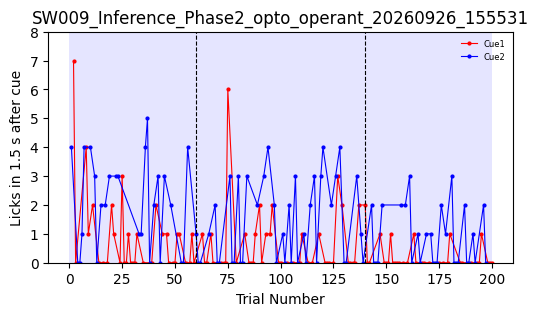

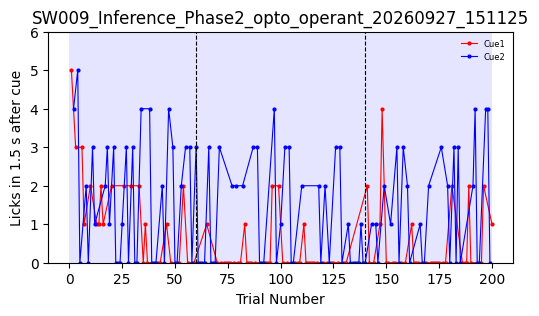

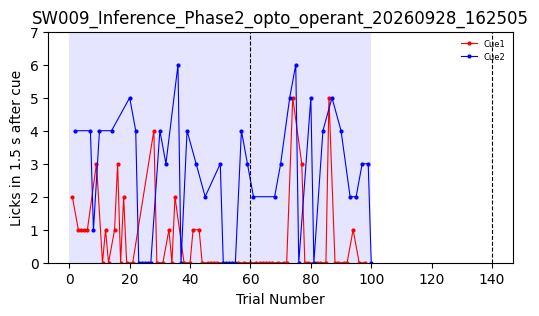

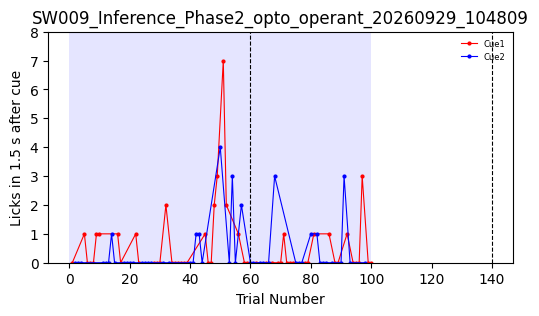

In [11]:
axes = {label: plot_session(session, title=label)
        for label, session in sessions.items()}
plt.show()

# Counts and latency side by side for every session:
# for label, session in sessions.items():
#     fig, (left, right) = plt.subplots(1, 2, figsize=(12, 3), dpi=DPI)
#     plot_session(session, title=label, ax=left, metric="count")
#     plot_session(session, title=label, ax=right, metric="latency")
#     fig.tight_layout()


## Summary -- mean licks per cue, and the latency distribution

Left panel: mean licks in the window per cue, with `ERROR` ("sem" or "std") error
bars. Right panel: the first-lick latencies as a histogram, one color per cue, its
legend giving the share of that cue's trials with a lick inside the window. Each panel
title carries the Cue1-vs-Cue2 p-value for that metric, from the `TEST` set in
**Style** (`"mannwhitney"` by default, or `"ttest"` / `"ks"`). Everything here is
styled from the **Style** cell, so re-run that and this cell to restyle.


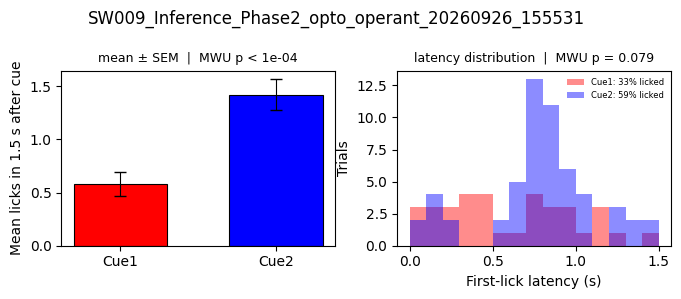

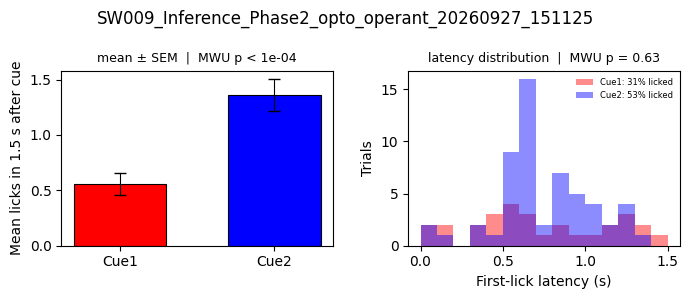

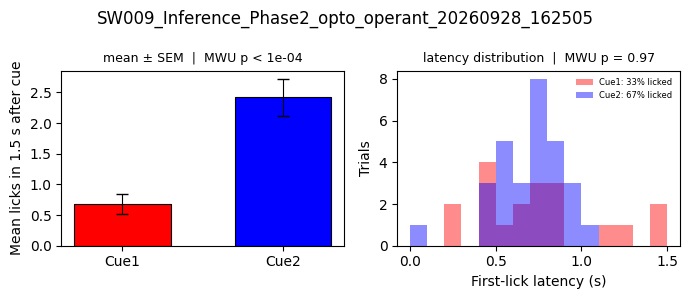

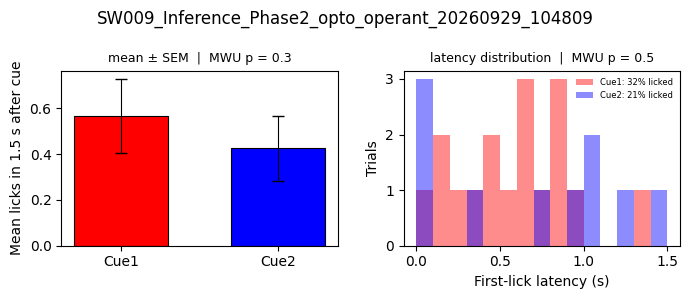

In [12]:
TEST_NAMES = {"mannwhitney": "MWU", "ttest": "t-test", "ks": "KS"}


def summary_stats(counts):
    """Mean and error bar for one cue's counts, honoring ERROR."""
    values = counts[~np.isnan(counts)]
    if values.size == 0:
        return np.nan, 0.0
    spread = np.std(values, ddof=1) if values.size > 1 else 0.0
    error = spread / np.sqrt(values.size) if ERROR == "sem" else spread
    return values.mean(), error


def p_value(cue_1, cue_2):
    """Cue1-vs-Cue2 p-value for one metric, honoring TEST. NaNs dropped."""
    a = cue_1[~np.isnan(cue_1)]
    b = cue_2[~np.isnan(cue_2)]
    if a.size < 2 or b.size < 2:
        return np.nan
    if TEST == "ttest":
        return stats.ttest_ind(a, b, equal_var=False).pvalue
    if TEST == "ks":
        return stats.ks_2samp(a, b).pvalue
    return stats.mannwhitneyu(a, b, alternative="two-sided").pvalue


def p_label(cue_1, cue_2):
    """Test name + p-value, e.g. "MWU p = 0.0021", for a panel title."""
    p = p_value(cue_1, cue_2)
    name = TEST_NAMES.get(TEST, TEST)
    if np.isnan(p):
        return f"{name} p = n/a"
    return f"{name} p < 1e-04" if p < 1e-4 else f"{name} p = {p:.2g}"


def plot_summary(session, title="", axes=None):
    """Bar plot of mean licks per cue + latency histogram. Returns the Axes."""
    window = session.get("window")
    cues = ((session["count_1"], session["latency_1"], CUE1),
            (session["count_2"], session["latency_2"], CUE2))

    own_figure = axes is None
    if own_figure:
        fig, axes = plt.subplots(1, 2, figsize=SUMMARY_FIGSIZE, dpi=DPI)
        name = title.rsplit("/", 1)[-1] if TITLE_AFTER_SLASH else title
        if name:
            fig.suptitle(name)
    bar_ax, hist_ax = axes

    # --- Mean licks per cue, with error bars ---
    stats = [summary_stats(count[0]) for count, _, _ in cues]
    labels = [style.get("label", f"Cue{i}")
              for i, (_, _, style) in enumerate(cues, start=1)]
    bar_ax.bar([0, 1], [m for m, _ in stats],
               yerr=[e for _, e in stats],
               color=[style["color"] for _, _, style in cues],
               error_kw=ERROR_STYLE, **BAR_STYLE)
    bar_ax.set_xticks([0, 1])
    bar_ax.set_xticklabels(labels)
    bar_ax.set_ylabel(f"Mean licks in {window:g} s after cue" if window
                      else "Mean licks in cue")
    bar_ax.set_title(f"mean ± {ERROR.upper()}  |  "
                     + p_label(session["count_1"][0], session["count_2"][0]),
                     fontsize=9)

    # --- Latency distribution ---
    bins = np.linspace(0, window, HIST_BINS + 1) if window else HIST_BINS
    for (_, latency, style), label in zip(cues, labels):
        raw = latency[0]
        values = raw[~np.isnan(raw)]
        # A trial counts as licked when its first lick landed inside the
        # window; misses sit at exactly the window length, or are NaN when
        # the session was loaded with MISS = np.nan.
        licked = np.count_nonzero(raw < window) if window else values.size
        share = 100 * licked / raw.size if raw.size else np.nan
        if values.size:
            hist_ax.hist(values, bins=bins, color=style["color"],
                         label=f"{label}: {share:.0f}% licked", **HIST_STYLE)
    hist_ax.set_xlabel("First-lick latency (s)")
    hist_ax.set_ylabel("Trials")
    # Misses sit at the window length, so they count as the slowest possible
    # latency here. Load with MISS = np.nan to test only trials that licked.
    hist_ax.set_title("latency distribution  |  "
                      + p_label(session["latency_1"][0],
                                session["latency_2"][0]),
                      fontsize=9)
    if LEGEND is not None:
        hist_ax.legend(**LEGEND)

    if GRID is not None:
        bar_ax.grid(**GRID)
        hist_ax.grid(**GRID)
    if own_figure:
        fig.tight_layout()

    return bar_ax, hist_ax


for label, session in sessions.items():
    plot_summary(session, title=label)
plt.show()


## Recipes

```python
# Switch metric for one plot without touching METRIC:
label = list(sessions)[0]
plot_session(sessions[label], title=label, metric="latency")

# A different counting window, without reloading the .mat files:
c1, c2 = count_licks(sessions[label]["data"], window=3.0)
l1, l2 = first_lick_latency(sessions[label]["data"], window=3.0)

# Misses left out of the latency trace instead of pinned at the window:
l1, l2 = first_lick_latency(sessions[label]["data"], miss=np.nan)

# Summary panels pooled over every loaded session:
pooled = {key: np.hstack([s[key] for s in sessions.values()])
          for key in ("count_1", "count_2", "latency_1", "latency_2")}
pooled["window"] = WINDOW
plot_summary(pooled, title="all sessions")

# Printed numbers, if you still want them alongside the plots:
for label, session in sessions.items():
    print(label, "| mean licks Cue1/Cue2:",
          summary_stats(session["count_1"][0])[0].round(2),
          summary_stats(session["count_2"][0])[0].round(2),
          "| blocks:", describe_blocks(session["data"]))

# One session on its own, tweaked ad hoc:
ax = plot_session(sessions[label], title=label)
ax.axvline(100, color="g", linewidth=1.5)
ax.set_xlim(0, 150)

# All sessions stacked in one figure:
fig, axs = plt.subplots(len(sessions), 1, figsize=(6, 3 * len(sessions)),
                        dpi=DPI, sharex=True)
for ax, (label, session) in zip(np.atleast_1d(axs), sessions.items()):
    plot_session(session, title=label, ax=ax)
fig.tight_layout()

# No block shading:
SHADE_ALPHA = 0        # then re-run the Plot cell

# Save what you see:
ax = plot_session(sessions[label], title=label)
ax.figure.savefig("session.png", dpi=300, bbox_inches="tight")
```
